In [56]:
import os
import boto3
import sagemaker
from sagemaker.serializers import IdentitySerializer
from sagemaker.deserializers import JSONDeserializer
from sagemaker.predictor import Predictor
import pandas as pd
import numpy as np
import time
from datetime import datetime, timezone
from pyathena import connect
from sqlalchemy import create_engine
from pprint import pprint
from sklearn.metrics import accuracy_score, classification_report
import io
import boto3
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from pathlib import Path
import uuid
import tarfile
from pprint import pprint
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import models
import torchvision.transforms as T

sns.set_theme()

In [57]:
%store -r
%store

Stored variables and their in-db values:
bucket                                     -> 'sagemaker-us-east-1-298748835671'
database_name                              -> 'cat_landmarking'
ingest_create_athena_db_passed             -> True
ingestion_completed                        -> True
landmarks_table                            -> 'cat_annotations'
manifest_table                             -> 'image_manifest'
project_prefix                             -> 'cat-landmarks-project'
s3_athena_results_dir                      -> 's3://sagemaker-us-east-1-298748835671/cat-landmar
s3_processed_cats_prefix                   -> 's3://sagemaker-us-east-1-298748835671/cat-landmar
s3_processed_combined_prefix               -> 's3://sagemaker-us-east-1-298748835671/cat-landmar
s3_raw_cats_prefix                         -> 's3://sagemaker-us-east-1-298748835671/cat-landmar
s3_raw_noncats_prefix                      -> 's3://sagemaker-us-east-1-298748835671/cat-landmar
s3_staging_dir                

In [58]:
# Reassigning store variables for IDE convenience
bucket = bucket
database_name = database_name
project_prefix = project_prefix
landmarks_table = landmarks_table
s3_staging_dir = s3_staging_dir
s3_raw_cats_prefix = s3_raw_cats_prefix
manifest_table = manifest_table

In [59]:
s3 = boto3.client("s3")
sagemaker_session = sagemaker.Session()
role = sagemaker.get_execution_role()
region = sagemaker_session._region_name

boto_session = boto3.Session(region_name=region)
sagemaker_client = boto_session.client(service_name="sagemaker", 
                                       region_name=region)


# SQL connection specification
engine = create_engine(
    f"awsathena+rest://@athena.{region}.amazonaws.com:443/"
    f"{database_name}"
    f"?s3_staging_dir={s3_staging_dir}"
)

s3_athena_results_dir = f"s3://{bucket}/{project_prefix}/athena/results/"

In [60]:
%store s3_athena_results_dir

Stored 's3_athena_results_dir' (str)


### Building Datasets for Modelling

In [61]:
statement_image_manifest = f"""
	select *
	from
		{database_name}.{manifest_table}
"""

image_manifest_df = pd.read_sql(statement_image_manifest, engine)
image_manifest_df.head()

,remote_path,local_path,file_size,width,height,label,ingest_time
0,s3://sagemaker-us-east-1-298748835671/cat-land...,data/raw/noncats/noncat_images/000000098304.jpg,111609,640,424,0,2026-02-17T18:26:46.318504
1,s3://sagemaker-us-east-1-298748835671/cat-land...,data/raw/noncats/noncat_images/000000425988.jpg,137421,640,498,0,2026-02-17T18:26:46.318512
2,s3://sagemaker-us-east-1-298748835671/cat-land...,data/raw/noncats/noncat_images/000000229381.jpg,120545,456,640,0,2026-02-17T18:26:46.318514
3,s3://sagemaker-us-east-1-298748835671/cat-land...,data/raw/noncats/noncat_images/000000393225.jpg,174759,640,428,0,2026-02-17T18:26:46.318516
4,s3://sagemaker-us-east-1-298748835671/cat-land...,data/raw/noncats/noncat_images/000000032779.jpg,154333,480,640,0,2026-02-17T18:26:46.318518


In [62]:
statement_landmarks = f"""
	select *
	from
		{database_name}.{landmarks_table}
"""

landmarks_df = pd.read_sql(statement_landmarks, engine)
landmarks_df["split"].value_counts()

split
train         11994
production     4001
test            999
validation      999
Name: count, dtype: int64

In [63]:
# splitting non-cats data
noncats_df = image_manifest_df[image_manifest_df["label"]==0]
cats_df = image_manifest_df[image_manifest_df["label"]==1]

np.random.seed(42)
noncats_df = noncats_df.copy()
noncats_df["split"] = noncats_df["remote_path"].apply(
    lambda _: np.random.choice(["train", "test", "validation"], p=[.8, .1, .1])
)

# creating data manifest from training, testing, and validation
training_manifest_features = ["remote_path", "label", "split"]
training_manifest = pd.concat([noncats_df[training_manifest_features], 
                              landmarks_df[training_manifest_features]])

training_manifest[["label", "split"]].value_counts().sort_index()

label  split     
0      test           1523
       train         12007
       validation     1470
1      production     4001
       test            999
       train         11994
       validation      999
Name: count, dtype: int64

In [64]:
if not Path("data/processed/combined").exists():
    os.makedir("data/processed/combined")

# Saving local copy of training manifest
training_manifest_local_path = "data/processed/combined/training_manifest_021626.pqt"
training_manifest.to_parquet(training_manifest_local_path)

# Saving training manifest to S3
training_manifest_remote_path = f"{project_prefix}/data/processed/combined/training_manifests/training_manifest_021626.pqt"
s3.upload_file(training_manifest_local_path, bucket, training_manifest_remote_path)

### Modelling for Classification

In [65]:
# Helper function to read in image
def read_image_from_s3_uri(s3_uri: str) -> Image.Image:
    bucket, key = s3_uri.replace("s3://", "").split("/", 1)
    try:
        obj = s3.get_object(Bucket=bucket, Key=key)
    except Exception as e:
        tqdm.write(f"[ERROR]: {e} - Key: {key}")
    
    if obj:
        return Image.open(io.BytesIO(obj["Body"].read())).convert("RGB")
     

# Dataset builder
class CatClsDatasetCls(Dataset):
    def __init__(self, df: pd.DataFrame, image_size=(224,224), 
                 uri_col: str = None, label_col: str = None):
        
        self.df = df.reset_index(drop=True)
        self.image_size = tuple(image_size)
        self.uri_col = uri_col
        self.label_col = label_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        s3_uri = row[self.uri_col]
        label = int(row[self.label_col])
        img = read_image_from_s3_uri(s3_uri)
        img = img.resize(self.image_size)
        transform = T.Compose([
			T.ToTensor(),
			T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
		])
        x = transform(img)
        y = torch.tensor(label, dtype=torch.long)
        return x, y

In [66]:
IMG_SIZE = 224

# Creating Dataset objects for each split
train_ds_cls = CatClsDatasetCls(
    training_manifest[training_manifest["split"]=="train"], 
    image_size=(IMG_SIZE, IMG_SIZE), 
    uri_col="remote_path", 
    label_col="label")

val_ds_cls   = CatClsDatasetCls(
    training_manifest[training_manifest["split"]=="validation"], 
    image_size=(IMG_SIZE, IMG_SIZE), 
    uri_col="remote_path", 
    label_col="label")

test_ds_cls  = CatClsDatasetCls(
    training_manifest[training_manifest["split"]=="test"], 
    image_size=(IMG_SIZE, IMG_SIZE), 
    uri_col="remote_path", 
    label_col="label")

In [67]:
#  Creating batches for training / validation / testing
BATCH_SIZE = 64

train_loader_cls = DataLoader(train_ds_cls, batch_size=BATCH_SIZE, 
                              shuffle=True, num_workers=16, pin_memory=True)

val_loader_cls   = DataLoader(val_ds_cls, batch_size=BATCH_SIZE, 
                              shuffle=False,num_workers=16, pin_memory=True)

test_loader_cls  = DataLoader(test_ds_cls, batch_size=BATCH_SIZE, 
                              shuffle=False,num_workers=16, pin_memory=True)

### Model Training

In [68]:
""" class SmallCNN(nn.Module):
    def __init__(self, num_classes: int = 2, dropout: float = 0.5):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2)
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.gap(x).flatten(1)
        x = self.dropout(x)
        return self.fc(x) """


def create_model_and_optimizer(num_classes=2, lr=0.001, freeze_backbone=True):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    model = models.resnet18(pretrained=True)
    
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
    
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model = model.to(device)
    params_to_optimize = model.fc.parameters() if freeze_backbone else model.parameters()
    
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(params_to_optimize, lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )
    return model, criterion, optimizer, scheduler, device


def run_one_epoch(model, loader, criterion, optimizer, device, train_mode: bool, epoch: int, num_epochs: int):
    model.train() if train_mode else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    phase = "Train" if train_mode else "Val"
    batches = len(loader)

    pbar = tqdm(
        enumerate(loader),
        total=batches,
        desc=f"Epoch {epoch}/{num_epochs} [{phase}]",
        leave=False,
        unit="batch",
    )

    batch_start = time.time()

    with torch.set_grad_enabled(train_mode):
        for batch_idx, (xb, yb) in pbar:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)

            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * xb.size(0)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == yb).sum().item()
            total += xb.size(0)

            # Update progress bar with running stats after each batch
            running_loss = total_loss / total
            running_acc = correct / total
            secs_per_batch = (time.time() - batch_start) / (batch_idx + 1)
            batches_left = batches - (batch_idx + 1)
            eta_secs = int(secs_per_batch * batches_left)

            pbar.set_postfix({
                "loss": f"{running_loss:.4f}",
                "acc":  f"{running_acc:.3f}",
                "batch ETA": f"{eta_secs}s",
            })

    return total_loss / max(total, 1), correct / max(total, 1)


def train_model(model, train_loader, val_loader, criterion, 
                optimizer, scheduler, device, num_epochs: int):
    """Outer training loop with per-epoch summary and overall ETA."""
    best_val_loss = float("inf")
    train_start = time.time()

    epoch_pbar = tqdm(range(1, num_epochs + 1), 
                      desc="Overall progress", unit="epoch")

    for epoch in epoch_pbar:
        epoch_start = time.time()

        train_loss, train_acc = run_one_epoch(
            model, train_loader, criterion, optimizer, device,
            train_mode=True, epoch=epoch, num_epochs=num_epochs
        )
        val_loss, val_acc = run_one_epoch(
            model, val_loader, criterion, optimizer, device,
            train_mode=False, epoch=epoch, num_epochs=num_epochs
        )

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        epoch_secs = time.time() - epoch_start
        elapsed = time.time() - train_start
        epochs_left = num_epochs - epoch
        eta_secs = int(epoch_secs * epochs_left)
        eta_str = time.strftime("%Hh %Mm %Ss", time.gmtime(eta_secs))

        # Mark best model
        improved = "✓ best" if val_loss < best_val_loss else ""
        if val_loss < best_val_loss:
            best_val_loss = val_loss

        # Clean per-epoch summary line
        print(
            f"Epoch {epoch:>3}/{num_epochs} | "
            f"Train loss: {train_loss:.4f}  acc: {train_acc:.3f} | "
            f"Val loss: {val_loss:.4f}  acc: {val_acc:.3f} | "
            f"LR: {current_lr:.2e} | "
            f"Epoch time: {epoch_secs:.1f}s | "
            f"ETA: {eta_str}  {improved}"
        )

        epoch_pbar.set_postfix({"val_loss": f"{val_loss:.4f}", "ETA": eta_str})

    total_time = time.strftime("%Hh %Mm %Ss", time.gmtime(time.time() - train_start))
    print(f"\nTraining complete in {total_time}. Best val loss: {best_val_loss:.4f}")

# Model Training

In [69]:
training_uuid = uuid.uuid4()
training_uuid

UUID('1ed1fb2a-aad1-4019-a688-ecfa2c11da29')

In [70]:
num_epochs = 4
model, criterion, optimizer, scheduler, device = create_model_and_optimizer()
print(f"Device: {device}")

metrics = []

for epoch in range(num_epochs):
    train_loss, train_acc = run_one_epoch(
        model, train_loader_cls, criterion, optimizer, device, 
        train_mode=True, epoch=epoch, num_epochs=num_epochs
    )
    
    val_loss, val_acc = run_one_epoch(
        model, val_loader_cls, criterion, optimizer, device, 
        train_mode=False, epoch=epoch, num_epochs=num_epochs
    )
    
    scheduler.step(val_loss)
    
    metrics.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc
    })
    
    print(f"Epoch {epoch}: Train Loss={train_loss:.4f}, "
          f"Train Acc={train_acc:.4f}, Val Loss={val_loss:.4f}, "
          f"Val Acc={val_acc:.4f}")

Device: cuda


/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
                                                                                                              

Epoch 0: Train Loss=0.1169, Train Acc=0.9628, Val Loss=0.0701, Val Acc=0.9793


Epoch 1: Train Loss=0.0695, Train Acc=0.9763, Val Loss=0.0655, Val Acc=0.9822


Epoch 2: Train Loss=0.0643, Train Acc=0.9778, Val Loss=0.0634, Val Acc=0.9818


Epoch 3: Train Loss=0.0611, Train Acc=0.9795, Val Loss=0.0735, Val Acc=0.9789


# Preserving Training Results Data

In [71]:
# Save CNN training metrics locally
metrics_df = pd.DataFrame(metrics)
metrics_df["training_uuid"] = metrics_df["epoch"].apply(lambda _: training_uuid)

training_metrics_path = Path("models/metrics")
training_metrics_file = training_metrics_path / f"cnn_training_metrics_{training_uuid}"

if not training_metrics_path.exists():
    os.makedirs(training_metrics_path)

metrics_df.to_csv(training_metrics_file, index=False)
metrics_df.tail()

,epoch,train_loss,train_acc,val_loss,val_acc,training_uuid
0,0,0.116861,0.962835,0.070079,0.979344,1ed1fb2a-aad1-4019-a688-ecfa2c11da29
1,1,0.069466,0.976251,0.065498,0.982179,1ed1fb2a-aad1-4019-a688-ecfa2c11da29
2,2,0.064301,0.977751,0.063368,0.981774,1ed1fb2a-aad1-4019-a688-ecfa2c11da29
3,3,0.061140,0.979543,0.073482,0.978939,1ed1fb2a-aad1-4019-a688-ecfa2c11da29


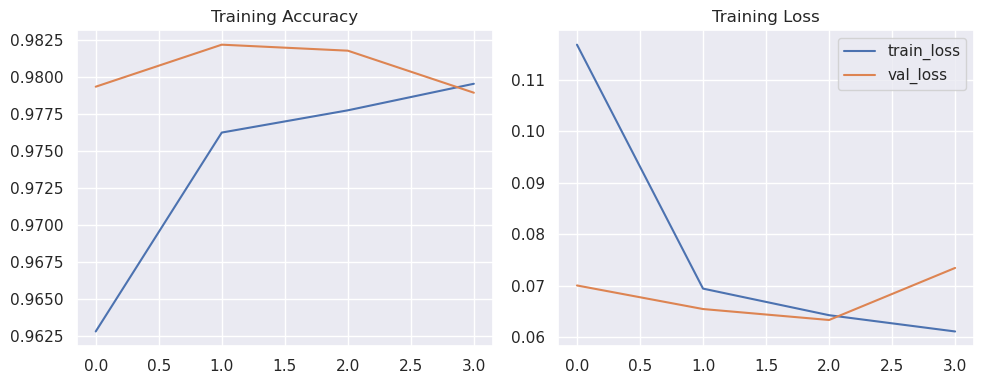

In [72]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].plot(metrics_df["epoch"], metrics_df["train_acc"], label="train_acc")
ax[0].plot(metrics_df["epoch"], metrics_df["val_acc"], label="val_acc")
ax[0].set_title("Training Accuracy")

ax[1].plot(metrics_df["epoch"], metrics_df["train_loss"], label="train_loss")
ax[1].plot(metrics_df["epoch"], metrics_df["val_loss"], label="val_loss")
ax[1].set_title("Training Loss")

plt.legend()
plt.tight_layout()
plt.show()

In [73]:
#  Upload CNN metrics to S3 for persistence
key = f"{project_prefix}/{training_metrics_file}"

s3.upload_file(training_metrics_file, bucket, key)
print(f"Uploaded to s3://{bucket}/{key}")

Uploaded to s3://sagemaker-us-east-1-298748835671/cat-landmarks-project/models/metrics/cnn_training_metrics_1ed1fb2a-aad1-4019-a688-ecfa2c11da29


In [74]:
eval_metrics = []

# Evaluate on test set once after training
te_loss, te_acc = run_one_epoch(model, test_loader_cls, criterion, optimizer, device, 
                                train_mode=False, epoch=1, num_epochs=1)
print("Test loss:", te_loss, "Test acc:", te_acc)
metrics.append({
    "epoch": "test_final",
    "test_loss": te_loss,
    "test_acc": te_acc,
})

eval_metrics_df = pd.DataFrame(eval_metrics)

eval_metrics_file = training_metrics_path / f"eval_metrics_{training_uuid}.csv"
eval_metrics_df.to_csv(eval_metrics_file, index=False)

# Upload results to S3
key = f"{project_prefix}/{eval_metrics_file}"
s3.upload_file(eval_metrics_file, bucket, key)

Test loss: 0.06423990055327847 Test acc: 0.9766058683584457


# Preserving Model Artifact

In [75]:
# Saving model artifact to disk
model_artifacts_dir = Path("models/artifacts")

if not model_artifacts_dir.exists():
    os.makedirs(model_artifacts_dir)
    
model_path = model_artifacts_dir / f"model_cls_{training_uuid}.pth"

torch.save(model.state_dict(), model_path)
print("Saved trained model to:", model_path)

Saved trained model to: models/artifacts/model_cls_1ed1fb2a-aad1-4019-a688-ecfa2c11da29.pth


## Endpoint creation/ deployment

In [76]:
model_archive_path = model_artifacts_dir / f"model_cls_{training_uuid}.tar.gz"

with tarfile.open(model_archive_path, "w:gz") as tar:
    tar.add(model_path, arcname="model.pth")        # flat, not nested path
    tar.add("inference.py", arcname="code/inference.py")

In [77]:
#  Upload packaged model to S3
endpoint_key = f"{project_prefix}/{model_archive_path}"
s3.upload_file(model_archive_path, bucket, endpoint_key)
print(f"Uploaded to s3://{bucket}/{endpoint_key}")

Uploaded to s3://sagemaker-us-east-1-298748835671/cat-landmarks-project/models/artifacts/model_cls_1ed1fb2a-aad1-4019-a688-ecfa2c11da29.tar.gz


In [78]:
# Update an existing endpoint to use the NEW model artifact without increasing instance count
# Creates: new Model -> new EndpointConfig -> UpdateEndpoint
endpoint_name = f"pytorch-inference-{training_uuid}" 
model_name = f"catcls-model-{training_uuid}"
endpoint_config_name = f"catcls-epc-{training_uuid}"

model_data_url = f"s3://{bucket}/{endpoint_key}"
image_uri = sagemaker.image_uris.retrieve(
    framework="pytorch",
    region=region,
    version="1.13",
    py_version="py39",
    instance_type="ml.g5.4xlarge",
    image_scope="inference",
)

# 1) Create SageMaker Model that points to the fixed artifact
try:
	sagemaker_client.create_model(
		ModelName=model_name,
		ExecutionRoleArn=role,
		PrimaryContainer={
			"Image": image_uri,
			"ModelDataUrl": model_data_url,
			"Environment": {
				# optional while debugging
				"SAGEMAKER_MODEL_SERVER_WORKERS": "1"
			},
		},
	)
except Exception as e:
    print(e)
    pass

# 2) Create new EndpointConfig (same instance type/count as existing)
sagemaker_client.create_endpoint_config(
    EndpointConfigName=endpoint_config_name,
    ProductionVariants=[{
        "VariantName": "AllTraffic",
        "ModelName": model_name,
        "InitialInstanceCount": 1,
        "InstanceType": "ml.g5.4xlarge",
    }],
)

try:
	sagemaker_client.update_endpoint(
		EndpointName=endpoint_name,
		EndpointConfigName=endpoint_config_name,
	)
except Exception as e:
    sagemaker_client.create_endpoint(
		EndpointName=endpoint_name,
		EndpointConfigName=endpoint_config_name,
	)

print("UpdateEndpoint started:", endpoint_name)

while True:
    desc = sagemaker_client.describe_endpoint(EndpointName=endpoint_name)
    status = desc["EndpointStatus"]
    print("Status:", status)
    if status == "InService":
        break
    if status == "Failed":
        print("Reason:", desc.get("FailureReason", ""))
        break
    time.sleep(20)

UpdateEndpoint started: pytorch-inference-1ed1fb2a-aad1-4019-a688-ecfa2c11da29
Status: Creating
Status: Creating
Status: Creating
Status: Creating
Status: Creating
Status: Creating
Status: Creating
Status: Creating
Status: Creating
Status: Creating
Status: Creating
Status: Creating
Status: Creating
Status: InService


## Inference

In [80]:
#  Reconnecting to latest endpoint
predictor = Predictor(
    endpoint_name=endpoint_name,
    serializer=IdentitySerializer("application/x-image"),
    deserializer=JSONDeserializer()
)

print("Connected to:", endpoint_name)

Connected to: pytorch-inference-1ed1fb2a-aad1-4019-a688-ecfa2c11da29


In [81]:
label_map = dict(zip(training_manifest["remote_path"], training_manifest["label"]))
test_uris = training_manifest.loc[training_manifest["split"] == "test", "remote_path"].values

rows = []
for uri in tqdm(test_uris, desc="Performing Batch Inference", unit="image"):
    label = label_map[uri]
    key = uri.replace(f"s3://{bucket}/", "")
    
    try:
        payload = s3.get_object(Bucket=bucket, Key=key)["Body"].read()
        result = predictor.predict(payload)
        pred = np.argmax(result["logits"][0])
        rows.append({"uri": uri, "label": label, "pred": pred, "error": None})
    except Exception as e:
        print(f"Failed on {uri}: {e}")
        rows.append({"uri": uri, "label": label, "pred": None, "error": str(e)})

test_df = pd.DataFrame(rows)
print(f"Completed: {test_df['pred'].notna().sum()}/{len(test_df)} successful")

Performing Batch Inference: 100%|██████████| 2522/2522 [04:14<00:00,  9.91image/s]

Completed: 2522/2522 successful


In [82]:
test_df.head()

,uri,label,pred,error
0,s3://sagemaker-us-east-1-298748835671/cat-land...,0,0,None
1,s3://sagemaker-us-east-1-298748835671/cat-land...,0,0,None
2,s3://sagemaker-us-east-1-298748835671/cat-land...,0,0,None
3,s3://sagemaker-us-east-1-298748835671/cat-land...,0,0,None
4,s3://sagemaker-us-east-1-298748835671/cat-land...,0,0,None


In [83]:
pprint(classification_report(test_df["label"], test_df["pred"]))

('              precision    recall  f1-score   support\n'
 '\n'
 '           0       0.97      0.99      0.98      1523\n'
 '           1       0.99      0.95      0.97       999\n'
 '\n'
 '    accuracy                           0.98      2522\n'
 '   macro avg       0.98      0.97      0.98      2522\n'
 'weighted avg       0.98      0.98      0.98      2522\n')


<Axes: >

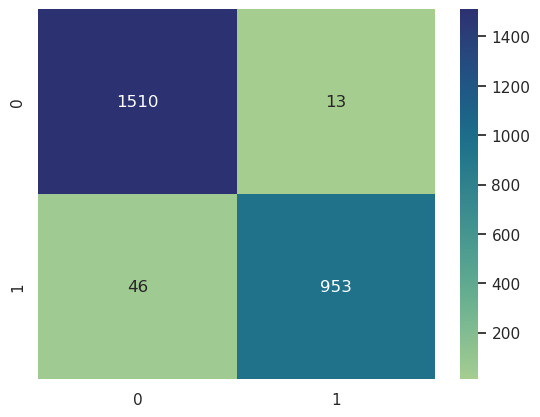

In [ ]:


fig, ax = plt.subplots()
sns.heatmap(confusion_matrix(test_df["label"], test_df["pred"]), 
            annot=True, fmt=".0f", cmap="crest")